# EDA and Data Cleaning

UCI Default of Credit Card Clients dataset. 30,000 rows, demographic info,
payment history, bill amounts, and default outcome.

Known quirks to check and document:
- `EDUCATION` and `MARRIAGE` have undocumented category codes (0, 5, 6 in
  EDUCATION; 0 in MARRIAGE) not covered by the official data dictionary.
- `PAY_0`..`PAY_6` repayment status codes include -2 and 0 which are not
  documented in the original UCI description.
- Column is literally named `PAY_0` instead of `PAY_1` (off-by-one naming
  inconsistency in the source data).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../data/default_credit_card.csv')
df = df.rename(columns={'default payment next month': 'DEFAULT'})
print(df.shape)
df.head()

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   30000 non-nu

In [4]:
df.isnull().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

## EDUCATION and MARRIAGE cleanup

Documented codes:
- EDUCATION: 1 graduate school, 2 university, 3 high school, 4 others
- MARRIAGE: 1 married, 2 single, 3 others

But the data contains extra undocumented codes.

In [6]:
print(df['EDUCATION'].value_counts())
print()
print(df['MARRIAGE'].value_counts())

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


In [7]:
# Fold undocumented EDUCATION codes (0, 5, 6) into the existing 'others' bucket (4)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# Fold undocumented MARRIAGE code (0) into the existing 'others' bucket (3)
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print(df['EDUCATION'].value_counts())
print()
print(df['MARRIAGE'].value_counts())

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64


## PAY_0..PAY_6 repayment status cleanup

Documented codes: -1 pay duly, 1-9 months delayed.
Undocumented codes present in the data: -2 and 0. Based on how the dataset is
commonly interpreted, -2 means no consumption / no balance to pay, and 0 means
the balance was paid using revolving credit (not officially late, not fully
settled either). Both are kept as distinct values rather than merged into -1,
since collapsing them would erase a real distinction in repayment behavior.

In [8]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for c in pay_cols:
    print(c, sorted(df[c].unique()))

PAY_0 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


## Class balance

In [9]:
df['DEFAULT'].value_counts(normalize=True)

DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64

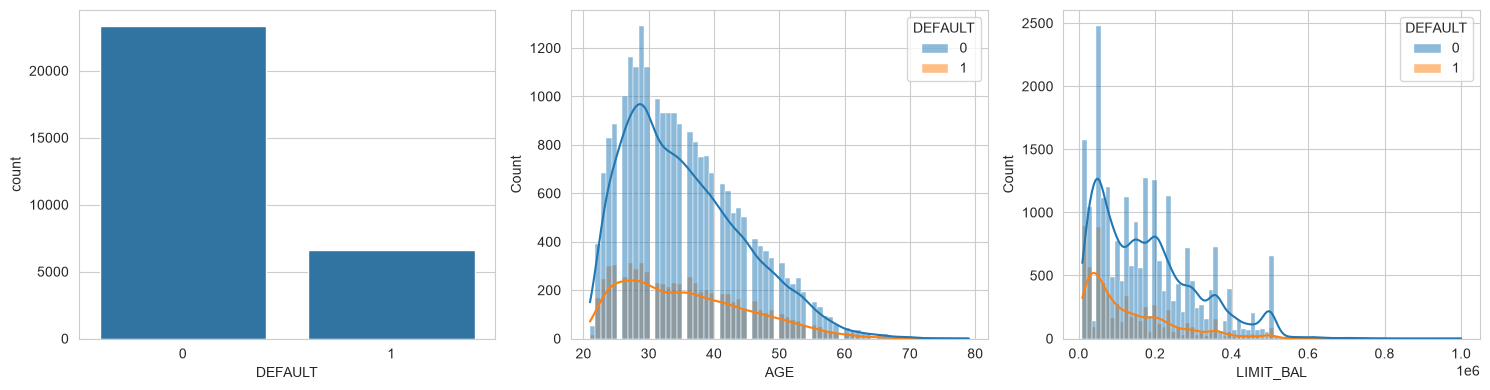

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x='DEFAULT', ax=axes[0])
sns.histplot(data=df, x='AGE', hue='DEFAULT', kde=True, ax=axes[1])
sns.histplot(data=df, x='LIMIT_BAL', hue='DEFAULT', kde=True, ax=axes[2])
plt.tight_layout()

In [11]:
df.to_csv('../data/default_credit_card_clean.csv', index=False)
print('saved cleaned dataset')

saved cleaned dataset
